# Data jobs

1. Скачать и объединить датасеты:
- data analyst
- data engineer
- data scientist
- business analyst
2. Изучить и проанализировать представленные в нем данные.
3. Провести предобработку данных. Обоснуйте выбранные способы предобработки.
4. Кластеризовать полученный объединенный датасет на 4 кластера.
5. Построить графики, оцените разбиение. Сравнить полученное разбиение относительно изначальных датасетов.

## Импорт библиотек

In [5]:
!pip install category_encoders


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import warnings
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans

In [7]:
warnings.filterwarnings('ignore')

## Загрузка данных

In [8]:
data_analyst = pd.read_csv('../data/DataAnalyst.csv')
data_science = pd.read_csv('../data/DataScientist.csv')
data_business = pd.read_csv('../data/BusinessAnalyst.csv')
data_engineer = pd.read_csv('../data/DataEngineer.csv')

In [9]:
data_analyst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   object 
 2   Salary Estimate    2253 non-null   object 
 3   Job Description    2253 non-null   object 
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   object 
 6   Location           2253 non-null   object 
 7   Headquarters       2253 non-null   object 
 8   Size               2253 non-null   object 
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   object 
 11  Industry           2253 non-null   object 
 12  Sector             2253 non-null   object 
 13  Revenue            2253 non-null   object 
 14  Competitors        2253 non-null   object 
 15  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(2),

| №  | Column            | Dtype   | Описание                                                                                 |
| -- | ----------------- | ------- | ---------------------------------------------------------------------------------------- |
| 0  | Unnamed: 0        | int64   | Индекс или порядковый номер строки.                                                      |
| 1  | Job Title         | object  | Название вакансии .                  |
| 2  | Salary Estimate   | object  | Оценка зарплаты в текстовом формате . |
| 3  | Job Description   | object  | Текстовое описание вакансии с требованиями, обязанностями и навыками.                    |
| 4  | Rating            | float64 | Рейтинг компании на сайте, может быть NaN.                         |
| 5  | Company Name      | object  | Название компании, предлагающей вакансию.                                                |
| 6  | Location          | object  | Местоположение вакансии (город, штат).                                                   |
| 7  | Headquarters      | object  | Местоположение главного офиса компании.                                                  |
| 8  | Size              | object  | Размер компании.                   |
| 9  | Founded           | int64   | Год основания компании.                                                                  |
| 10 | Type of ownership | object  | Тип собственности компании .                |
| 11 | Industry          | object  | Отрасль, в которой работает компания.    |
| 12 | Sector            | object  | Сектор экономики компании.                        |
| 13 | Revenue           | object  | Доход компании в текстовом формате.                     |
| 14 | Competitors       | object  | Основные конкуренты компании.                            |
| 15 | Easy Apply        | object  | Флаг "легкого отклика" на вакансию.                                             |


In [10]:
data_analyst.shape

(2253, 16)

In [11]:
data_science.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3909 non-null   int64  
 1   index              3909 non-null   int64  
 2   Job Title          3909 non-null   object 
 3   Salary Estimate    3909 non-null   object 
 4   Job Description    3909 non-null   object 
 5   Rating             3909 non-null   float64
 6   Company Name       3909 non-null   object 
 7   Location           3909 non-null   object 
 8   Headquarters       3909 non-null   object 
 9   Size               3909 non-null   object 
 10  Founded            3909 non-null   int64  
 11  Type of ownership  3909 non-null   object 
 12  Industry           3909 non-null   object 
 13  Sector             3909 non-null   object 
 14  Revenue            3909 non-null   object 
 15  Competitors        3909 non-null   object 
 16  Easy Apply         3909 

| №  | Column            | Dtype   | Описание                                                                                              |
| -- | ----------------- | ------- | ----------------------------------------------------------------------------------------------------- |
| 0  | Unnamed: 0        | int64   | Индекс или порядковый номер строки.                                                                   |
| 1  | index             | int64    |
| 2  | Job Title         | object  | Название вакансии.                           |
| 3  | Salary Estimate   | object  | Оценка зарплаты в текстовом формате.            |
| 4  | Job Description   | object  | Текстовое описание вакансии с требованиями, обязанностями и навыками.                                 |
| 5  | Rating            | float64 | Рейтинг компании на сайте, может быть NaN.                                      |
| 6  | Company Name      | object  | Название компании, предлагающей вакансию.                                                             |
| 7  | Location          | object  | Местоположение вакансии (город, штат).                                                                |
| 8  | Headquarters      | object  | Местоположение главного офиса компании.                                                               |
| 9  | Size              | object  | Размер компании                                 |
| 10 | Founded           | int64   | Год основания компании.                                                                               |
| 11 | Type of ownership | object  | Тип собственности компании.                             |
| 12 | Industry          | object  | Отрасль, в которой работает компания.                 |
| 13 | Sector            | object  | Сектор экономики компании .                                     |
| 14 | Revenue           | object  | Доход компании в текстовом формате.                                  |
| 15 | Competitors       | object  | Основные конкуренты компании.                                         |
| 16 | Easy Apply        | object  | Флаг "легкого отклика" на вакансию.                                                          |


In [12]:
data_science.shape

(3909, 17)

In [13]:
data_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4092 entries, 0 to 4091
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4092 non-null   object
 1   index              4092 non-null   object
 2   Job Title          4092 non-null   object
 3   Salary Estimate    4092 non-null   object
 4   Job Description    4092 non-null   object
 5   Rating             4092 non-null   object
 6   Company Name       4092 non-null   object
 7   Location           4092 non-null   object
 8   Headquarters       4092 non-null   object
 9   Size               4092 non-null   object
 10  Founded            4092 non-null   object
 11  Type of ownership  4092 non-null   object
 12  Industry           4092 non-null   object
 13  Sector             4092 non-null   object
 14  Revenue            4092 non-null   object
 15  Competitors        3692 non-null   object
 16  Easy Apply         3692 non-null   object


| №  | Column            | Dtype  | Описание                                                                              |
| -- | ----------------- | ------ | ------------------------------------------------------------------------------------- |
| 0  | Unnamed: 0        | object | Индекс или порядковый номер строки.   |
| 1  | index             | object |                                        |
| 2  | Job Title         | object | Название вакансии.       |
| 3  | Salary Estimate   | object | Оценка зарплаты в текстовом формате (например, "$60K-$90K").                          |
| 4  | Job Description   | object | Текстовое описание вакансии с требованиями, обязанностями и навыками.                 |
| 5  | Rating            | object | Рейтинг компании на сайте, представлен как текстовое поле.      |
| 6  | Company Name      | object | Название компании, предлагающей вакансию.                                             |
| 7  | Location          | object | Местоположение вакансии (город, штат).                                                |
| 8  | Headquarters      | object | Местоположение главного офиса компании.                                               |
| 9  | Size              | object | Размер компании.                |
| 10 | Founded           | object | Год основания компании, представлен как строка.                                       |
| 11 | Type of ownership | object | Тип собственности компании.             |
| 12 | Industry          | object | Отрасль, в которой работает компания. |
| 13 | Sector            | object | Сектор экономики компании.                     |
| 14 | Revenue           | object | Доход компании в текстовом формате.                  |
| 15 | Competitors       | object | Основные конкуренты компании, есть пропуски.          |
| 16 | Easy Apply        | object | Флаг "легкого отклика" на вакансию                       |


In [14]:
data_business.shape

(4092, 17)

In [15]:
data_engineer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2528 non-null   object 
 1   Salary Estimate    2528 non-null   object 
 2   Job Description    2528 non-null   object 
 3   Rating             2528 non-null   float64
 4   Company Name       2528 non-null   object 
 5   Location           2528 non-null   object 
 6   Headquarters       2528 non-null   object 
 7   Size               2528 non-null   object 
 8   Founded            2528 non-null   int64  
 9   Type of ownership  2528 non-null   object 
 10  Industry           2528 non-null   object 
 11  Sector             2528 non-null   object 
 12  Revenue            2528 non-null   object 
 13  Competitors        2528 non-null   object 
 14  Easy Apply         2528 non-null   object 
dtypes: float64(1), int64(1), object(13)
memory usage: 296.4+ KB


| №  | Column            | Dtype   | Описание                                                                              |
| -- | ----------------- | ------- | ------------------------------------------------------------------------------------- |
| 0  | Job Title         | object  | Название вакансии              |
| 1  | Salary Estimate   | object  | Оценка зарплаты в текстовом формате.                         |
| 2  | Job Description   | object  | Текстовое описание вакансии с требованиями, обязанностями и навыками.                 |
| 3  | Rating            | float64 | Рейтинг компании на сайте (например, Glassdoor), может быть NaN.                      |
| 4  | Company Name      | object  | Название компании, предлагающей вакансию.                                             |
| 5  | Location          | object  | Местоположение вакансии (город, штат).                                                |
| 6  | Headquarters      | object  | Местоположение главного офиса компании.                                               |
| 7  | Size              | object  | Размер компании.                |
| 8  | Founded           | int64   | Год основания компании.                                                               |
| 9  | Type of ownership | object  | Тип собственности компании.             |
| 10 | Industry          | object  | Отрасль, в которой работает компания. |
| 11 | Sector            | object  | Сектор экономики компании.                     |
| 12 | Revenue           | object  | Доход компании в текстовом формате.                  |
| 13 | Competitors       | object  | Основные конкуренты компании.                         |
| 14 | Easy Apply        | object  | Флаг "легкого отклика" на вакансию.                                          |


In [16]:
data_engineer.shape

(2528, 15)

## Объединение датасетов

In [17]:
data_analyst.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [18]:
data_business.head()

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Business Analyst - Clinical & Logistics Platform,$56K-$102K (Glassdoor est.),Company Overview\n\n\nAt Memorial Sloan Ketter...,3.9,Memorial Sloan-Kettering\n3.9,"New York, NY","New York, NY",10000+ employees,1884,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),"Mayo Clinic, The Johns Hopkins Hospital, MD An...",-1
1,1,1,Business Analyst,$56K-$102K (Glassdoor est.),We are seeking for an energetic and collaborat...,3.8,Paine Schwartz Partners\n3.8,"New York, NY","New York, NY",1 to 50 employees,-1,Company - Private,Venture Capital & Private Equity,Finance,Unknown / Non-Applicable,-1,True
2,2,2,Data Analyst,$56K-$102K (Glassdoor est.),"For more than a decade, Asembia has been worki...",3.6,Asembia\n3.6,"Florham Park, NJ","Florham Park, NJ",501 to 1000 employees,2004,Company - Private,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$5 to $10 million (USD),-1,-1
3,3,3,"Information Security Analyst, Incident Response",$56K-$102K (Glassdoor est.),Job Description Summary\nThe Information Secur...,3.6,BD\n3.6,"Franklin Lakes, NJ","Franklin Lakes, NJ",10000+ employees,1897,Company - Public,Health Care Products Manufacturing,Manufacturing,$10+ billion (USD),"Abbott, Siemens, Baxter",-1
4,4,4,Analyst - FP&A Global Revenue,$56K-$102K (Glassdoor est.),Magnite is the world's largest independent sel...,3.4,Rubicon Project\n3.4,"New York, NY","Los Angeles, CA",201 to 500 employees,2007,Company - Public,Internet,Information Technology,$100 to $500 million (USD),"PubMatic, AppNexus, Index Exchange",True


In [19]:
data_engineer.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,Data Engineer,$80K-$150K (Glassdoor est.),Company Description\nSagence is a management a...,4.5,Sagence\n4.5,"New York, NY","Chicago, IL",1 to 50 employees,2009,Company - Private,Consulting,Business Services,$10 to $25 million (USD),"WCI Consulting, PwC",-1
1,Senior Data Engineer (Healthcare Domain experi...,$80K-$150K (Glassdoor est.),"Key Responsibilities\n\n- Architect, build, an...",3.4,Enterprise Integration\n3.4,"New York, NY","Jacksonville, FL",51 to 200 employees,1998,Company - Private,IT Services,Information Technology,$25 to $50 million (USD),-1,-1
2,Data Engineers,$80K-$150K (Glassdoor est.),Overview\n\nJob description\n\nPosition Overvi...,5.0,Maestro Technologies\n5.0,"New York, NY","Trenton, NJ",51 to 200 employees,2003,Company - Private,IT Services,Information Technology,$5 to $10 million (USD),-1,-1
3,Client Trade Support Engineer,$80K-$150K (Glassdoor est.),About the Position\n\n\nThis position will sup...,4.8,Jane Street\n4.8,"New York, NY","New York, NY",501 to 1000 employees,2000,Company - Private,Investment Banking & Asset Management,Finance,Unknown / Non-Applicable,-1,-1
4,Data Engineer,$80K-$150K (Glassdoor est.),Data Engineer\n\nJob Details\nLevel\nExperienc...,3.7,GNY Insurance Companies\n3.7,"New York, NY","New York, NY",201 to 500 employees,1914,Company - Private,Insurance Carriers,Insurance,$100 to $500 million (USD),"Travelers, Chubb, Crum & Forster",True


In [20]:
data_science.head()

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,1,1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,2,2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
3,3,3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,4,4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1


In [21]:
# Удаляем лишние колонки
data_analyst = data_analyst.drop(columns=['Unnamed: 0'])
data_science = data_science.drop(columns=['Unnamed: 0', 'index'])
data_business = data_business.drop(columns=['Unnamed: 0', 'index'])
data_engineer = data_engineer

In [22]:
# Добавляем колонку с типом вакансии
data_analyst['Job_Type'] = 'Data Analyst'
data_science['Job_Type'] = 'Data Scientist'
data_business['Job_Type'] = 'Business Analyst'
data_engineer['Job_Type'] = 'Data Engineer'

In [23]:
df = pd.concat([data_analyst, data_science, data_business, data_engineer], ignore_index=True)

## 2. Преобразование датасета

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12782 entries, 0 to 12781
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Job Title          12782 non-null  object
 1   Salary Estimate    12782 non-null  object
 2   Job Description    12782 non-null  object
 3   Rating             12782 non-null  object
 4   Company Name       12781 non-null  object
 5   Location           12782 non-null  object
 6   Headquarters       12782 non-null  object
 7   Size               12782 non-null  object
 8   Founded            12782 non-null  object
 9   Type of ownership  12782 non-null  object
 10  Industry           12782 non-null  object
 11  Sector             12782 non-null  object
 12  Revenue            12782 non-null  object
 13  Competitors        12382 non-null  object
 14  Easy Apply         12382 non-null  object
 15  Job_Type           12782 non-null  object
dtypes: object(16)
memory usage: 1.6+ MB


In [25]:
df.shape

(12782, 16)

In [26]:
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,Job_Type
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True,Data Analyst
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,Data Analyst
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,Data Analyst
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,Data Analyst
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,Data Analyst


### Приведение типов

In [27]:
df['Easy Apply'] = df['Easy Apply'].replace({'True': True, 'False': False})
df['Easy Apply'] = df['Easy Apply'].replace("-1", False)
df['Easy Apply'] = df['Easy Apply'].astype('boolean')

In [28]:
df.replace("-1", np.nan, inplace=True)

In [29]:
df['Founded'] = pd.to_numeric(df['Founded'], errors='coerce').astype('Int64')  # nullable int
df['Founded'].replace(-1, np.nan, inplace=True)

In [30]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Rating'].replace(-1, np.nan, inplace=True)

In [31]:
df['Easy Apply'].unique()

<BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean

In [32]:
categorical_cols = ['Location', 'Headquarters',
                    'Type of ownership', 'Industry', 'Sector', 'Competitors', 'Job_Type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

### Очистка колонки с зарплатой

In [33]:
df['Salary Estimate'].unique()[:5]

array(['$37K-$66K (Glassdoor est.)', '$46K-$87K (Glassdoor est.)',
       '$51K-$88K (Glassdoor est.)', '$51K-$87K (Glassdoor est.)',
       '$59K-$85K (Glassdoor est.)'], dtype=object)

In [34]:
df[df['Salary Estimate'] == '$17-$27 Per Hour(Glassdoor est.)'].shape

(11, 16)

In [35]:
salary_mask = df['Salary Estimate'].str.contains(r'\$\d+', na=False)
wrong_salary = df[~salary_mask]
wrong_salary[['Salary Estimate', 'Job_Type']].head()


,Salary Estimate,Job_Type
2149,NaN,Data Analyst
9854,3.3,Business Analyst
9855,2.3,Business Analyst
9856,2.3,Business Analyst
9857,3.9,Business Analyst


In [36]:
df = df[~df['Salary Estimate'].str.contains('Per Hour', na=False)] # Удаляем зарплату по часу(их всего 10 штук)

In [37]:
df = df[df['Salary Estimate'].str.contains(r'\$\d+', na=False)].copy() # Берём, только где есть $

In [38]:
df['Salary_Clean'] = df['Salary Estimate'].str.replace(r'\(Glassdoor est.\)', '', regex=True).str.strip()

# Функция для преобразования диапазона зарплат в среднее число
def parse_salary(s):
    nums = re.findall(r'\d+', s.replace(',', ''))
    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return int(nums[0])
    else:
        return np.nan

# Создаём числовую колонку
df['Salary_Num'] = df['Salary_Clean'].apply(parse_salary)

In [39]:
df[['Salary Estimate', 'Salary_Clean', 'Salary_Num']].head(3)

,Salary Estimate,Salary_Clean,Salary_Num
0,$37K-$66K (Glassdoor est.),$37K-$66K,51.5
1,$37K-$66K (Glassdoor est.),$37K-$66K,51.5
2,$37K-$66K (Glassdoor est.),$37K-$66K,51.5


### Обработка size

In [40]:
df['Size'].unique()

array(['201 to 500 employees', '10000+ employees',
       '1001 to 5000 employees', '501 to 1000 employees',
       '5001 to 10000 employees', '1 to 50 employees',
       '51 to 200 employees', 'Unknown', nan], dtype=object)

In [41]:
def parse_size(s):
    if pd.isna(s) or s == 'Unknown':
        return np.nan
    s = s.replace(' employees', '').replace('+', '')
    parts = s.split(' to ')
    if len(parts) == 2:
        return (int(parts[0]) + int(parts[1])) / 2
    else:
        return int(parts[0])  # для значений типа '10000+'

df['Size_Num'] = df['Size'].apply(parse_size)

In [42]:
df[['Size', 'Size_Num']].head()

,Size,Size_Num
0,201 to 500 employees,350.5
1,10000+ employees,10000.0
2,1001 to 5000 employees,3000.5
3,201 to 500 employees,350.5
4,501 to 1000 employees,750.5


### Обработка дохода (Revenue)

In [43]:
df['Revenue'].unique()

array(['$100 to $500 million (USD)', '$2 to $5 billion (USD)',
       'Unknown / Non-Applicable', '$50 to $100 million (USD)',
       '$1 to $2 billion (USD)', '$5 to $10 billion (USD)',
       '$1 to $5 million (USD)', '$25 to $50 million (USD)',
       '$10+ billion (USD)', 'Less than $1 million (USD)',
       '$10 to $25 million (USD)', nan,
       '$500 million to $1 billion (USD)', '$5 to $10 million (USD)'],
      dtype=object)

In [44]:
def parse_revenue(s):
    if pd.isna(s) or 'Unknown' in s or 'Non-Applicable' in s:
        return np.nan

    s = s.replace('(USD)', '').replace(',', '').strip()

    # Обработка "Less than $1 million"
    if 'Less than' in s:
        num = re.findall(r'\d+', s)
        return float(num[0]) / 2  # берём половину, например 0.5 million

    # Обработка "$10+ billion"
    if '+' in s:
        num = re.findall(r'\d+', s)
        if 'billion' in s.lower():
            return float(num[0]) * 1000  # переводим в миллионы
        else:
            return float(num[0])

    # Диапазоны типа "$2 to $5 billion"
    nums = re.findall(r'\d+', s)
    if 'billion' in s.lower():
        nums = [float(n)*1000 for n in nums]  # переводим в миллионы
    else:
        nums = [float(n) for n in nums]

    if len(nums) == 2:
        return sum(nums)/2
    elif len(nums) == 1:
        return nums[0]
    else:
        return np.nan

df['Revenue_Num'] = df['Revenue'].apply(parse_revenue)

In [45]:
df[['Revenue_Num', 'Revenue']].head(5)

,Revenue_Num,Revenue
0,300.0,$100 to $500 million (USD)
1,3500.0,$2 to $5 billion (USD)
2,NaN,Unknown / Non-Applicable
3,75.0,$50 to $100 million (USD)
4,300.0,$100 to $500 million (USD)


### Удаление лишних столбцов

In [46]:
columns_to_drop = ['Salary Estimate', 'Salary_Clean', 'Job Description', 'Size', 'Revenue']
df.drop(columns=columns_to_drop, inplace=True)

In [47]:
df.shape

(12360, 15)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12360 entries, 0 to 12781
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Job Title          12360 non-null  object  
 1   Rating             11131 non-null  float64 
 2   Company Name       12359 non-null  object  
 3   Location           12360 non-null  category
 4   Headquarters       11627 non-null  category
 5   Founded            9212 non-null   Int64   
 6   Type of ownership  11662 non-null  category
 7   Industry           10621 non-null  category
 8   Sector             10624 non-null  category
 9   Competitors        3461 non-null   category
 10  Easy Apply         12360 non-null  boolean 
 11  Job_Type           12360 non-null  category
 12  Salary_Num         12360 non-null  float64 
 13  Size_Num           11395 non-null  float64 
 14  Revenue_Num        8315 non-null   float64 
dtypes: Int64(1), boolean(1), category(7), float64(4), object(2

| №  | Column             | Non-Null Count | Dtype     | Description |
|----|------------------|----------------|-----------|-------------|
| 0  | Job Title         | 12360          | category  | Название вакансии |
| 1  | Rating            | 12360          | float64   | Рейтинг компании |
| 2  | Company Name      | 12359          | category  | Название компании |
| 3  | Location          | 12360          | category  | Локация вакансии |
| 4  | Headquarters      | 11627          | category  | Штаб-квартира компании |
| 5  | Founded           | 11413          | Int64     | Год основания компании |
| 6  | Type of ownership | 11662          | category  | Тип собственности компании |
| 7  | Industry          | 10621          | category  | Отрасль компании |
| 8  | Sector            | 10624          | category  | Сектор компании |
| 9  | Competitors       | 3461           | category  | Конкуренты компании |
| 10 | Easy Apply        | 12360          | boolean   | Возможность отклика через Glassdoor |
| 11 | Job_Type          | 12360          | category  | Тип вакансии (роль) |
| 12 | Salary_Num        | 12360          | float64   | Средняя зарплата |
| 13 | Size_Num          | 11395          | float64   | Среднее количество сотрудников |
| 14 | Revenue_Num       | 8315           | float64   | Средняя выручка компании (млн $) |


In [49]:
df.describe()

,Rating,Founded,Salary_Num,Size_Num,Revenue_Num
count,11131.000000,9212.0,12360.000000,11395.000000,8315.000000
mean,3.777163,1977.212006,91.006634,3389.111847,14540.954600
std,0.639777,47.881829,34.693458,4058.751669,52633.376637
min,1.000000,1625.0,33.500000,25.500000,0.500000
25%,3.400000,1967.0,63.500000,125.500000,37.500000
50%,3.800000,1997.0,83.000000,750.500000,300.000000
75%,4.100000,2006.0,111.500000,7500.500000,7500.000000
max,5.000000,2020.0,225.000000,10000.000000,250500.000000


### Удаление выбросов

In [50]:
df.shape

(12360, 15)

In [51]:
df = df[(df['Revenue_Num'].isna()) | (df['Revenue_Num'] < 100_000)] # Сначала вручную

In [52]:
df.shape

(11968, 15)

In [53]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['Rating', 'Founded', 'Salary_Num', 'Size_Num', 'Revenue_Num']

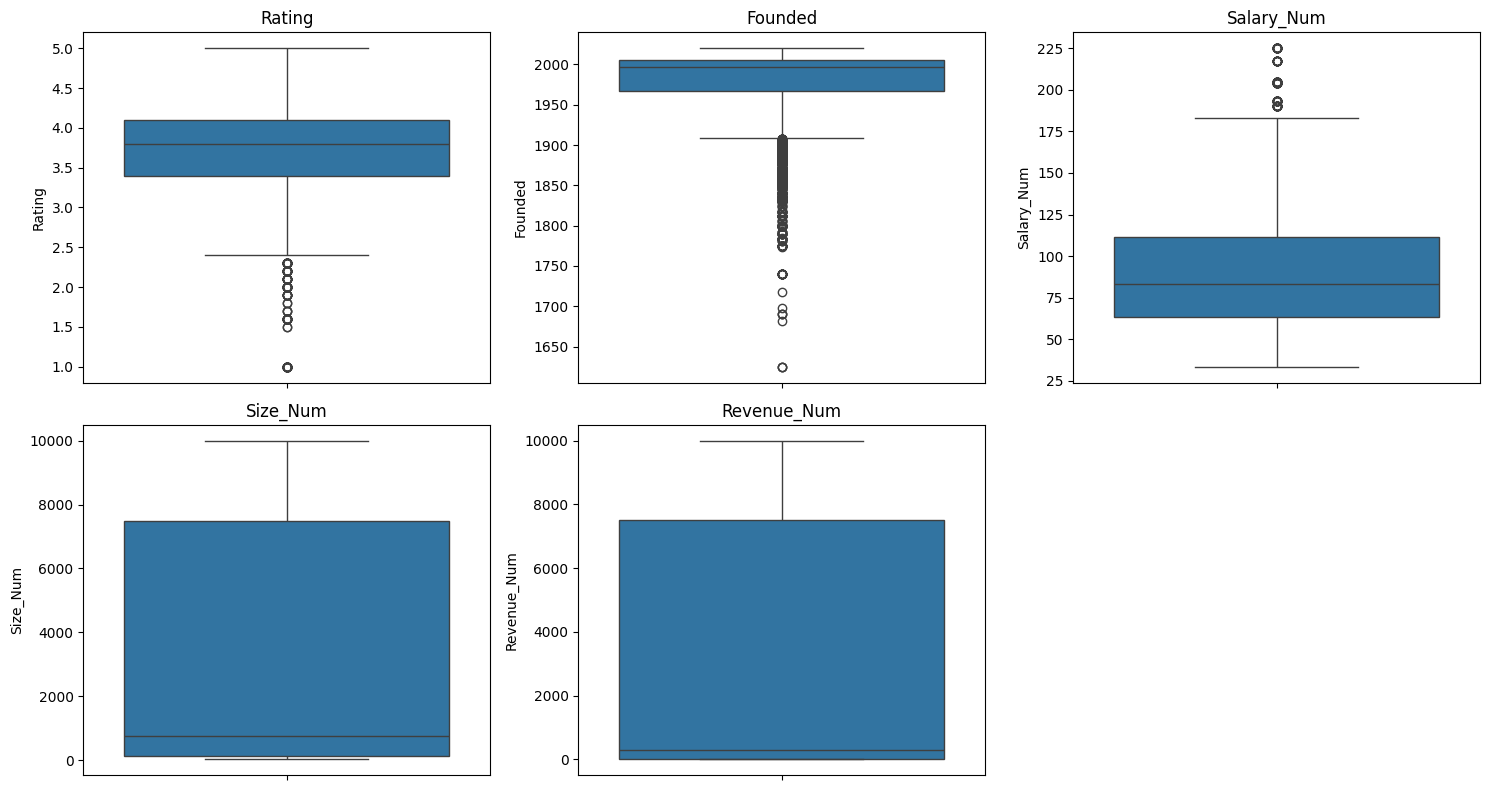

In [54]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [55]:
# Временно заполняем NaN медианой только для анализа выбросов
df_numeric = df[numeric_cols].copy()
df_numeric = df_numeric.fillna(df_numeric.median())

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42)
outliers = iso.fit_predict(X_scaled)

# Добавляем метку выброса в основной df
df["outlier"] = outliers

# Удаляем строки, помеченные как выброс
df_clean = df[df["outlier"] == 1].drop(columns=["outlier"])

print("Размер до очистки:", len(df))
print("Размер после удаления выбросов:", len(df_clean))

# Обновляем df
df = df_clean.copy()

Размер до очистки: 11968
Размер после удаления выбросов: 11608


In [56]:
df = df.reset_index(drop=True)

In [57]:
df.shape

(11608, 15)

In [58]:
df.describe()

,Rating,Founded,Salary_Num,Size_Num,Revenue_Num
count,10379.000000,8490.0,11608.000000,10643.000000,7607.000000
mean,3.788563,1981.619317,90.497373,3222.566898,2689.384383
std,0.644525,40.585693,33.730337,4044.083416,3938.365313
min,1.000000,1799.0,33.500000,25.500000,0.500000
25%,3.400000,1972.0,63.500000,125.500000,17.500000
50%,3.800000,1998.0,83.000000,750.500000,300.000000
75%,4.100000,2007.0,111.000000,7500.500000,3500.000000
max,5.000000,2020.0,225.000000,10000.000000,10000.000000


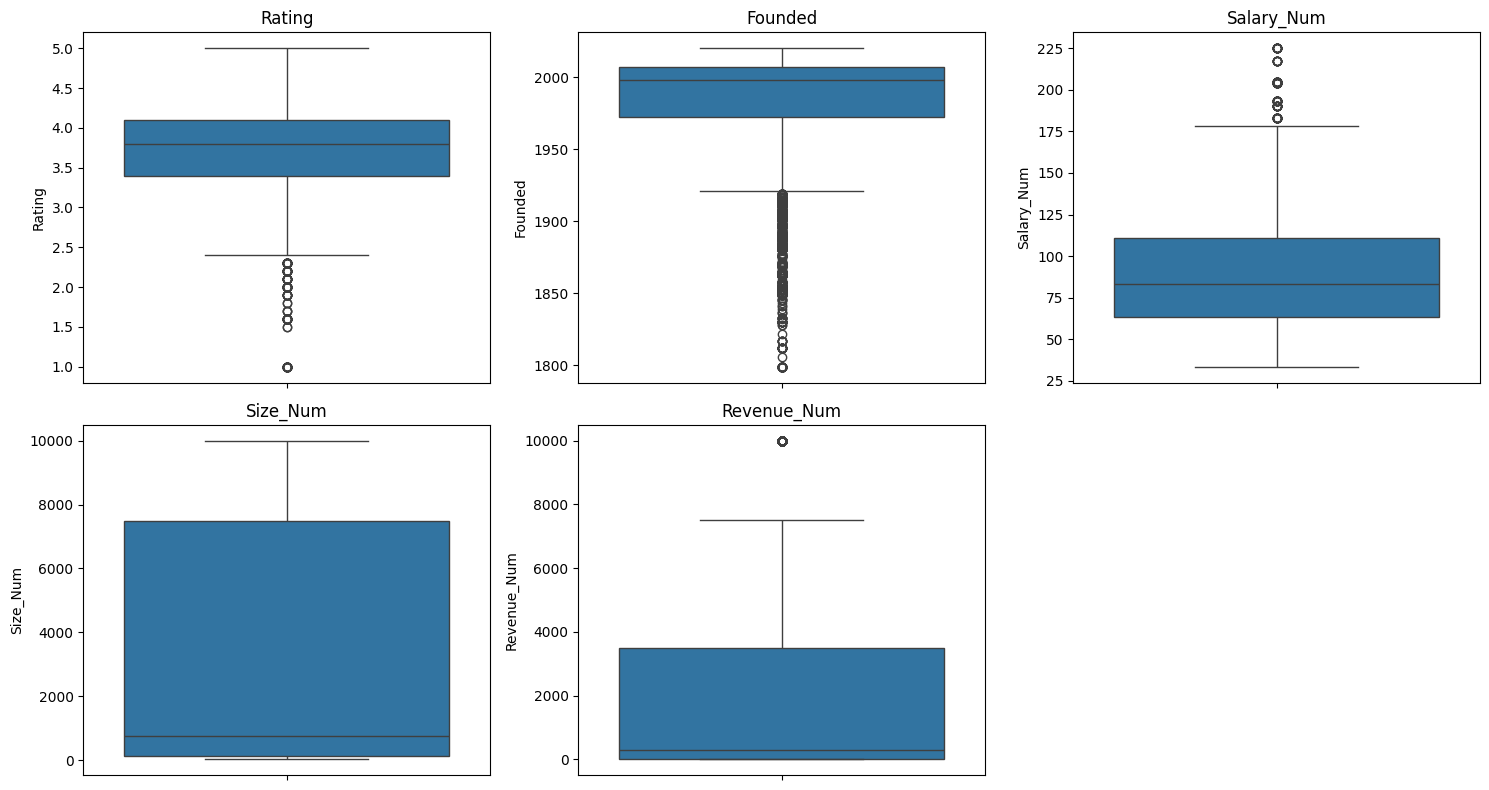

In [59]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Пропуски

In [60]:
df.isna().sum()

Job Title               0
Rating               1229
Company Name            1
Location                0
Headquarters          733
Founded              3118
Type of ownership     698
Industry             1734
Sector               1731
Competitors          8502
Easy Apply              0
Job_Type                0
Salary_Num              0
Size_Num              965
Revenue_Num          4001
dtype: int64

#### Удаление колонок

In [61]:
df.drop(columns=['Competitors', 'Headquarters'], inplace=True) # Много пропущенных значений/Не нужный столбец, т.к есть Location

#### Удаление строки

In [62]:
df = df.dropna(subset=['Company Name']) # Одна пропущенная строка

In [63]:
df.head()

,Job Title,Rating,Company Name,Location,Founded,Type of ownership,Industry,Sector,Easy Apply,Job_Type,Salary_Num,Size_Num,Revenue_Num
0,"Data Analyst, Center on Immigration and Justic...",3.2,Vera Institute of Justice\n3.2,"New York, NY",1961,Nonprofit Organization,Social Assistance,Non-Profit,True,Data Analyst,51.5,350.5,300.0
1,Quality Data Analyst,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY",1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,False,Data Analyst,51.5,10000.0,3500.0
2,"Senior Data Analyst, Insights & Analytics Team...",3.4,Squarespace\n3.4,"New York, NY",2003,Company - Private,Internet,Information Technology,False,Data Analyst,51.5,3000.5,NaN
3,Data Analyst,4.1,Celerity\n4.1,"New York, NY",2002,Subsidiary or Business Segment,IT Services,Information Technology,False,Data Analyst,51.5,350.5,75.0
4,Reporting Data Analyst,3.9,FanDuel\n3.9,"New York, NY",2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",True,Data Analyst,51.5,750.5,300.0


In [64]:
df.isna().sum()

Job Title               0
Rating               1228
Company Name            0
Location                0
Founded              3117
Type of ownership     697
Industry             1733
Sector               1730
Easy Apply              0
Job_Type                0
Salary_Num              0
Size_Num              964
Revenue_Num          4000
dtype: int64

#### Заполнение пропусков

In [65]:
# Числовые колонки
num_cols = ["Rating", "Founded", "Size_Num", "Revenue_Num"]

# Заполняем медианой
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Категориальные колонки
cat_cols = ["Type of ownership", "Industry", "Sector"]

for col in cat_cols:
    df[col] = df[col].astype("object").fillna("Unknown")
    df[col] = df[col].astype("category")  # обратно в категориальный

df.isna().sum()

Job Title            0
Rating               0
Company Name         0
Location             0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Easy Apply           0
Job_Type             0
Salary_Num           0
Size_Num             0
Revenue_Num          0
dtype: int64

In [66]:
df.describe()

,Rating,Founded,Salary_Num,Size_Num,Revenue_Num
count,11607.000000,11607.0,11607.000000,11607.000000,11607.000000
mean,3.789773,1986.018265,90.498622,3017.253511,1865.955630
std,0.609484,35.461603,33.731521,3932.127122,3384.453542
min,1.000000,1799.0,33.500000,25.500000,0.500000
25%,3.500000,1987.0,63.500000,125.500000,75.000000
50%,3.800000,1998.0,83.000000,750.500000,300.000000
75%,4.100000,2003.0,111.000000,7500.500000,1500.000000
max,5.000000,2020.0,225.000000,10000.000000,10000.000000


### Проверка на дубликаты

In [67]:
df.duplicated().sum()

np.int64(14)

In [68]:
df = df.drop_duplicates().reset_index(drop=True)

In [69]:
df.shape

(11593, 13)

### Масшатабирование признаков

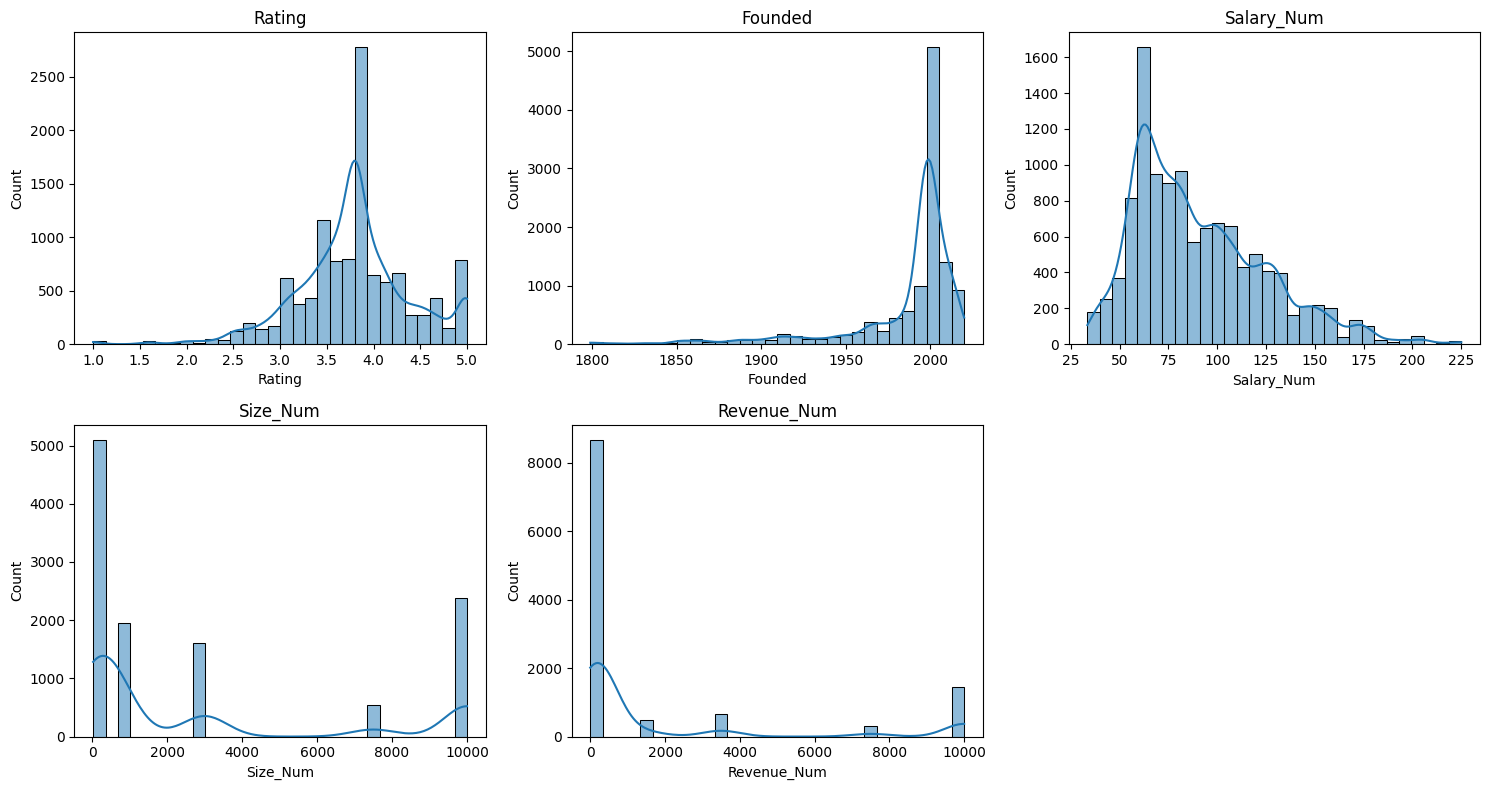

In [70]:
plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [71]:
skew_values = df[numeric_cols].skew()
skew_values

Rating        -0.329605
Founded       -2.588535
Salary_Num     0.908127
Size_Num       1.017412
Revenue_Num    1.789241
dtype: Float64

| Колонка     | Skew  | Нужно ли логарифмировать?                                                         |
| ----------- | ----- | --------------------------------------------------------------------------------- |
| Rating      | -0.33 | Почти симметрично                                                            |
| Founded     | -2.59 | Можно оставить как есть, год – это признак порядковый/категориальный для кластера |
| Salary_Num  | 0.91  | Лёгкая скошенность, логарифм можно                           |
| Size_Num    | 1.02  | Положительная скошенность, логарифм полезен                                      |
| Revenue_Num | 1.79  | Сильная положительная скошенность, нужен логарифм                        |


#### Логарифмирование

In [72]:
df["Size_Num_log"] = np.log1p(df["Size_Num"])
df["Revenue_Num_log"] = np.log1p(df["Revenue_Num"])

#### Нормализация

In [73]:
features_to_scale = ["Salary_Num", "Size_Num_log", "Revenue_Num_log", "Rating", "Founded"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_to_scale])

df_scaled = df.copy()
df_scaled[features_to_scale] = X_scaled

In [74]:
df_scaled = df_scaled.drop(columns=['Size_Num', 'Revenue_Num'])

In [75]:
df_scaled.describe()

,Rating,Founded,Salary_Num,Size_Num_log,Revenue_Num_log
count,1.159300e+04,1.159300e+04,1.159300e+04,1.159300e+04,1.159300e+04
mean,7.722624e-17,1.873043e-15,1.863236e-16,2.905178e-16,-1.838720e-16
std,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00
min,-4.576976e+00,-5.276483e+00,-1.689153e+00,-1.600255e+00,-2.231167e+00
25%,-4.754932e-01,2.745804e-02,-8.000591e-01,-8.363709e-01,-5.332783e-01
50%,1.668472e-02,3.377950e-01,-2.221482e-01,3.440750e-02,6.207840e-02
75%,5.088626e-01,4.788572e-01,6.076727e-01,1.158800e+00,7.570952e-01
max,1.985396e+00,9.584689e-01,3.986229e+00,1.299341e+00,1.577456e+00


In [76]:
numeric_cols = df_scaled.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['Rating', 'Founded', 'Salary_Num', 'Size_Num_log', 'Revenue_Num_log']

In [77]:
skew_values = df[numeric_cols].skew()
skew_values

Rating            -0.329605
Founded           -2.588535
Salary_Num         0.908127
Size_Num_log      -0.145982
Revenue_Num_log   -0.229138
dtype: Float64

In [78]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11593 entries, 0 to 11592
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Job Title          11593 non-null  object  
 1   Rating             11593 non-null  float64 
 2   Company Name       11593 non-null  object  
 3   Location           11593 non-null  category
 4   Founded            11593 non-null  float64 
 5   Type of ownership  11593 non-null  category
 6   Industry           11593 non-null  category
 7   Sector             11593 non-null  category
 8   Easy Apply         11593 non-null  boolean 
 9   Job_Type           11593 non-null  category
 10  Salary_Num         11593 non-null  float64 
 11  Size_Num_log       11593 non-null  float64 
 12  Revenue_Num_log    11593 non-null  float64 
dtypes: boolean(1), category(5), float64(5), object(2)
memory usage: 751.1+ KB


In [79]:
cat_cols = ["Job Title", "Company Name","Location", "Type of ownership", "Industry", "Sector", "Job_Type", ]
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Job Title: 5259 уникальных значений
Company Name: 4604 уникальных значений
Location: 392 уникальных значений
Type of ownership: 14 уникальных значений
Industry: 111 уникальных значений
Sector: 26 уникальных значений
Job_Type: 4 уникальных значений


| Колонка           | Уникальные значения | Тип кодировки     |
| ----------------- | ------------------- | ----------------- |
| Job Title         | 5259                | Не кодировать     |
| Company Name      | 4605                | Не кодировать     |
| Location          | 392                 | Не кодировать     |
| Type of ownership | 14                  | One-Hot Encoding  |
| Industry          | 111                 | Binary Encoding   |
| Sector            | 26                  | One-Hot Encoding  |
| Job_Type          | 4                   | Не кодировать     |

#### Кодирование

In [80]:
numeric_cols

['Rating', 'Founded', 'Salary_Num', 'Size_Num_log', 'Revenue_Num_log']

In [81]:
df_numeric = df_scaled[numeric_cols]
df_numeric.shape

(11593, 5)

In [82]:
# One-Hot Encoding для Type of ownership и Sector
df_onehot = pd.get_dummies(df_scaled[["Type of ownership", "Sector"]], drop_first=False)
df_onehot.shape

(11593, 40)

In [83]:
# Binary Encoding для Industry
binary_encoder = ce.BinaryEncoder(cols=["Industry"], return_df=True)
df_binary = binary_encoder.fit_transform(df_scaled[["Industry"]])
df_binary.shape

(11593, 7)

In [84]:
# Объединие для кластеризации
X_for_clustering = pd.concat([df_numeric.reset_index(drop=True),
                              df_onehot.reset_index(drop=True),
                              df_binary.reset_index(drop=True)],
                             axis=1)

In [85]:
X_for_clustering.shape

(11593, 52)

In [86]:
X_for_clustering.head()

,Rating,Founded,Salary_Num,Size_Num_log,Revenue_Num_log,Type of ownership_College / University,Type of ownership_Company - Private,Type of ownership_Company - Public,Type of ownership_Contract,Type of ownership_Franchise,...,Sector_Transportation & Logistics,Sector_Travel & Tourism,Sector_Unknown,Industry_0,Industry_1,Industry_2,Industry_3,Industry_4,Industry_5,Industry_6
0,-0.967671,-0.706066,-1.155697,-0.336936,0.062078,False,False,False,False,False,...,False,False,False,0,0,0,0,0,0,1
1,0.016685,-2.624512,-1.155697,1.299341,1.123432,False,False,False,False,False,...,False,False,False,0,0,0,0,0,1,0
2,-0.639552,0.478857,-1.155697,0.711156,0.062078,False,True,False,False,False,...,False,False,False,0,0,0,0,0,1,1
3,0.508863,0.450645,-1.155697,-0.336936,-0.533278,False,False,False,False,False,...,False,False,False,0,0,0,0,1,0,0
4,0.180744,0.648132,-1.155697,0.034408,0.062078,False,True,False,False,False,...,False,False,False,0,0,0,0,1,0,1


## Кластеризация

In [87]:
df["Job_Type"].value_counts()

Job_Type
Data Scientist      3599
Business Analyst    3490
Data Engineer       2398
Data Analyst        2106
Name: count, dtype: int64

Data Scientist	-> Business Analyst -> Data Engineer -> Data Analyst

### Kmeans

In [88]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Обучение KMeans
cluster_labels = kmeans.fit_predict(X_for_clustering)

In [89]:
df["Cluster_kmeans"] = cluster_labels

In [90]:
df["Cluster_kmeans"].value_counts()

Cluster_kmeans
1    4418
0    3497
3    2612
2    1066
Name: count, dtype: int64

#### Оценка точности

#### ARI

In [91]:
ari = adjusted_rand_score(df["Job_Type"], df["Cluster_kmeans"])
print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.00013803560521869892


#### NMI

In [92]:
nmi = normalized_mutual_info_score(df["Job_Type"], df["Cluster_kmeans"])
print("Normalized Mutual Information:", nmi)

Normalized Mutual Information: 0.0048071924263970245


#### Silhouette Score

In [93]:
sil_score = silhouette_score(X_for_clustering, df["Cluster_kmeans"])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.14241065466524733


In [94]:
df["Cluster_kmeans"].value_counts()

Cluster_kmeans
1    4418
0    3497
3    2612
2    1066
Name: count, dtype: int64

#### Тепловая карта

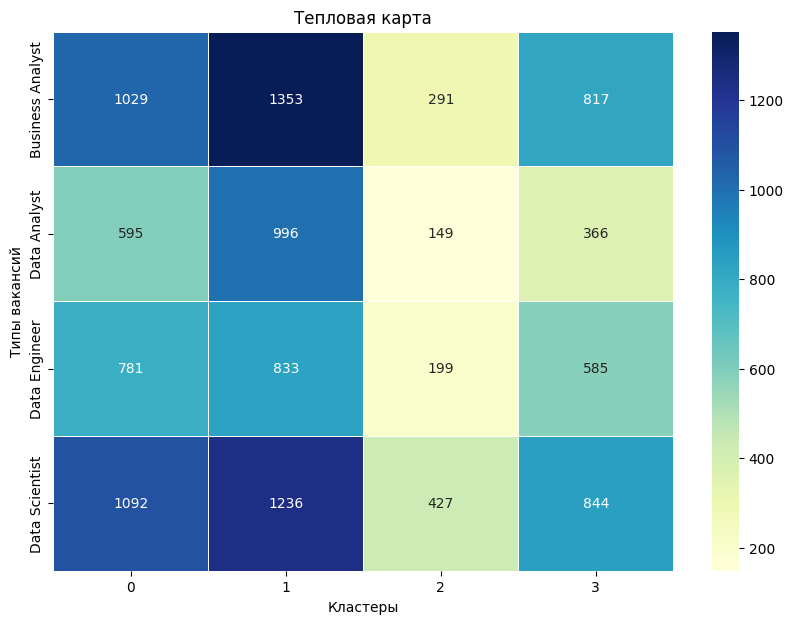

In [95]:
job_cluster_table = pd.crosstab(df["Job_Type"], df["Cluster_kmeans"])

# Построим тепловую карту
plt.figure(figsize=(10, 7))
sns.heatmap(job_cluster_table, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Тепловая карта")
plt.xlabel("Кластеры")
plt.ylabel("Типы вакансий")
plt.show()

### Agglomerative Clustering

In [96]:
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')

# Обучение
cluster_labels = agg.fit_predict(X_for_clustering)

In [97]:
df["Cluster_agg"] = cluster_labels

#### Оценка точности

#### ARI

In [98]:
ari = adjusted_rand_score(df["Job_Type"], df["Cluster_agg"])
print("Agglomerative Clustering - Adjusted Rand Index:", ari)

Agglomerative Clustering - Adjusted Rand Index: -5.498805695120479e-05


#### NMI

In [99]:
nmi = normalized_mutual_info_score(df["Job_Type"], df["Cluster_agg"])
print("Agglomerative Clustering - Normalized Mutual Information:", nmi)

Agglomerative Clustering - Normalized Mutual Information: 0.0045504866934567186


#### Silhouette Score

In [100]:
sil_score = silhouette_score(X_for_clustering, df["Cluster_agg"])
print("Agglomerative Clustering - Silhouette Score:", sil_score)

Agglomerative Clustering - Silhouette Score: 0.104668491998065


In [101]:
df["Cluster_agg"].value_counts()

Cluster_agg
0    5790
2    2891
1    1882
3    1030
Name: count, dtype: int64

#### Тепловая карта

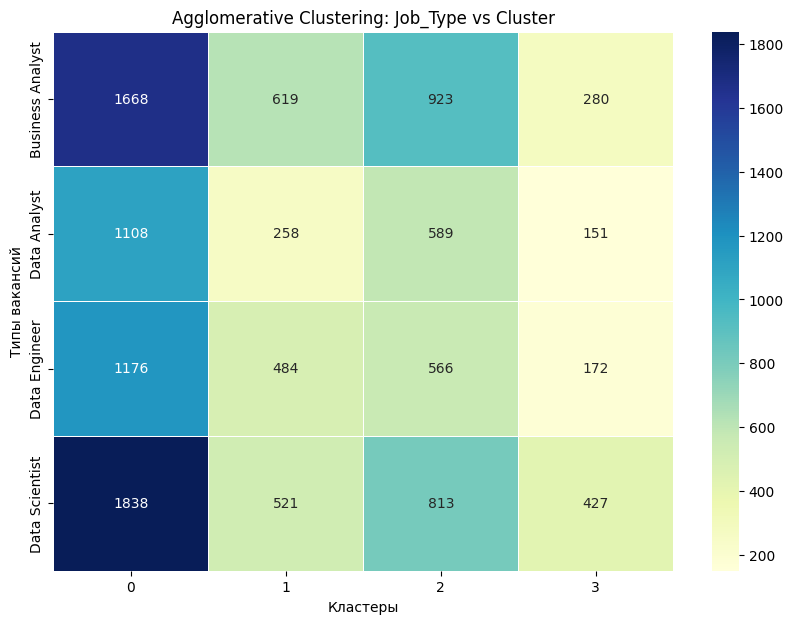

In [102]:
job_cluster_table = pd.crosstab(df["Job_Type"], df["Cluster_agg"])
plt.figure(figsize=(10, 7))
sns.heatmap(job_cluster_table, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Agglomerative Clustering: Job_Type vs Cluster")
plt.xlabel("Кластеры")
plt.ylabel("Типы вакансий")
plt.show()

### Spectral Clustering

In [103]:
spectral = SpectralClustering(n_clusters=4,
                              random_state=42,
                              assign_labels='kmeans')


# Обучение
cluster_labels = spectral.fit_predict(X_for_clustering)

In [104]:
df["Cluster_spectral"] = cluster_labels

In [105]:
df["Cluster_spectral"].value_counts()

Cluster_spectral
0    11250
3      307
2       23
1       13
Name: count, dtype: int64

#### Оценка точности

#### ARI

In [106]:
ari = adjusted_rand_score(df["Job_Type"], df["Cluster_spectral"])
print("Spectral Clustering - Adjusted Rand Index:", ari)

Spectral Clustering - Adjusted Rand Index: 0.000203340674302228


#### NMI

In [107]:
nmi = normalized_mutual_info_score(df["Job_Type"], df["Cluster_spectral"])
print("Spectral Clustering - Normalized Mutual Information:", nmi)

Spectral Clustering - Normalized Mutual Information: 0.0018666790601277437


#### Silhouette Score

In [108]:
sil_score = silhouette_score(X_for_clustering, df["Cluster_spectral"])
print("Spectral Clustering - Silhouette Score:", sil_score)

Spectral Clustering - Silhouette Score: 0.2387449304485234


#### Тепловая карта

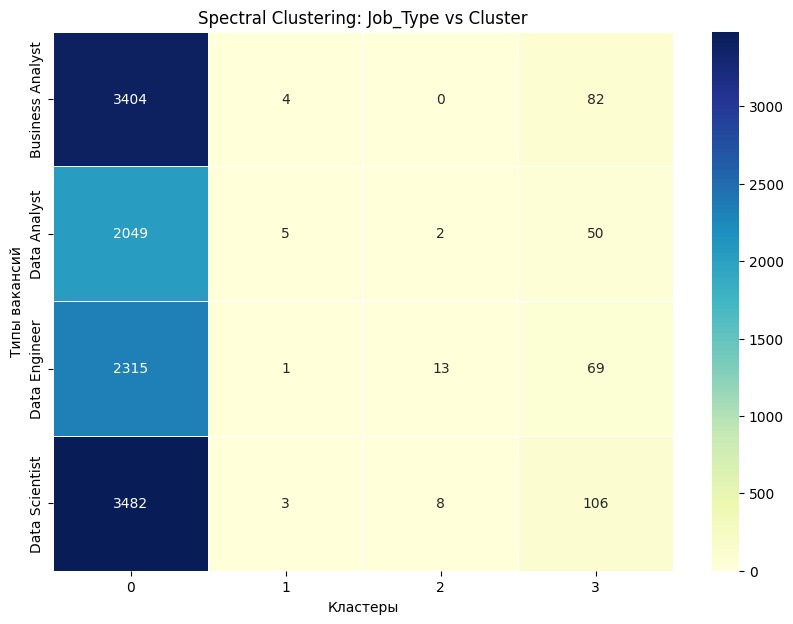

In [109]:
job_cluster_table = pd.crosstab(df["Job_Type"], df["Cluster_spectral"])
plt.figure(figsize=(10, 7))
sns.heatmap(job_cluster_table, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Spectral Clustering: Job_Type vs Cluster")
plt.xlabel("Кластеры")
plt.ylabel("Типы вакансий")
plt.show()

Всё в один класс попало

### Gaussian Mixture (EM)

In [110]:
gmm = GaussianMixture(n_components=4,
                      random_state=42)


# Обучение
cluster_labels = gmm.fit_predict(X_for_clustering)

In [111]:
df["Cluster_gmm"] = cluster_labels


In [112]:
df["Cluster_gmm"].value_counts()

Cluster_gmm
1    7463
0    2234
3    1016
2     880
Name: count, dtype: int64

#### Оценка точности

#### ARI

In [113]:
ari = adjusted_rand_score(df["Job_Type"], df["Cluster_gmm"])
print("Gaussian Mixture - Adjusted Rand Index:", ari)

Gaussian Mixture - Adjusted Rand Index: -0.0006062281609750317


#### NMI

In [114]:
nmi = normalized_mutual_info_score(df["Job_Type"], df["Cluster_gmm"])
print("Gaussian Mixture - Normalized Mutual Information:", nmi)

Gaussian Mixture - Normalized Mutual Information: 0.0029482354291892584


#### Silhouette Score

In [115]:
sil_score = silhouette_score(X_for_clustering, df["Cluster_gmm"])
print("Gaussian Mixture - Silhouette Score:", sil_score)

Gaussian Mixture - Silhouette Score: 0.007338747404630827


#### Тепловая карта

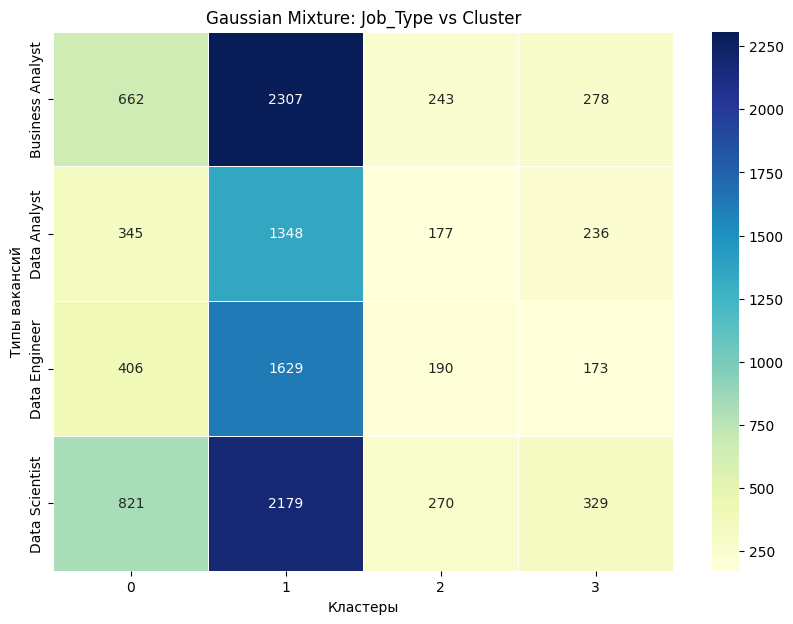

In [116]:
job_cluster_table = pd.crosstab(df["Job_Type"], df["Cluster_gmm"])
plt.figure(figsize=(10, 7))
sns.heatmap(job_cluster_table, annot=True, cmap="YlGnBu", fmt="d", linewidths=0.5)
plt.title("Gaussian Mixture: Job_Type vs Cluster")
plt.xlabel("Кластеры")
plt.ylabel("Типы вакансий")
plt.show()

## Визуализация

Лучший - kmeans, Agglomerative Clustering

### PCA

#### Kmeans

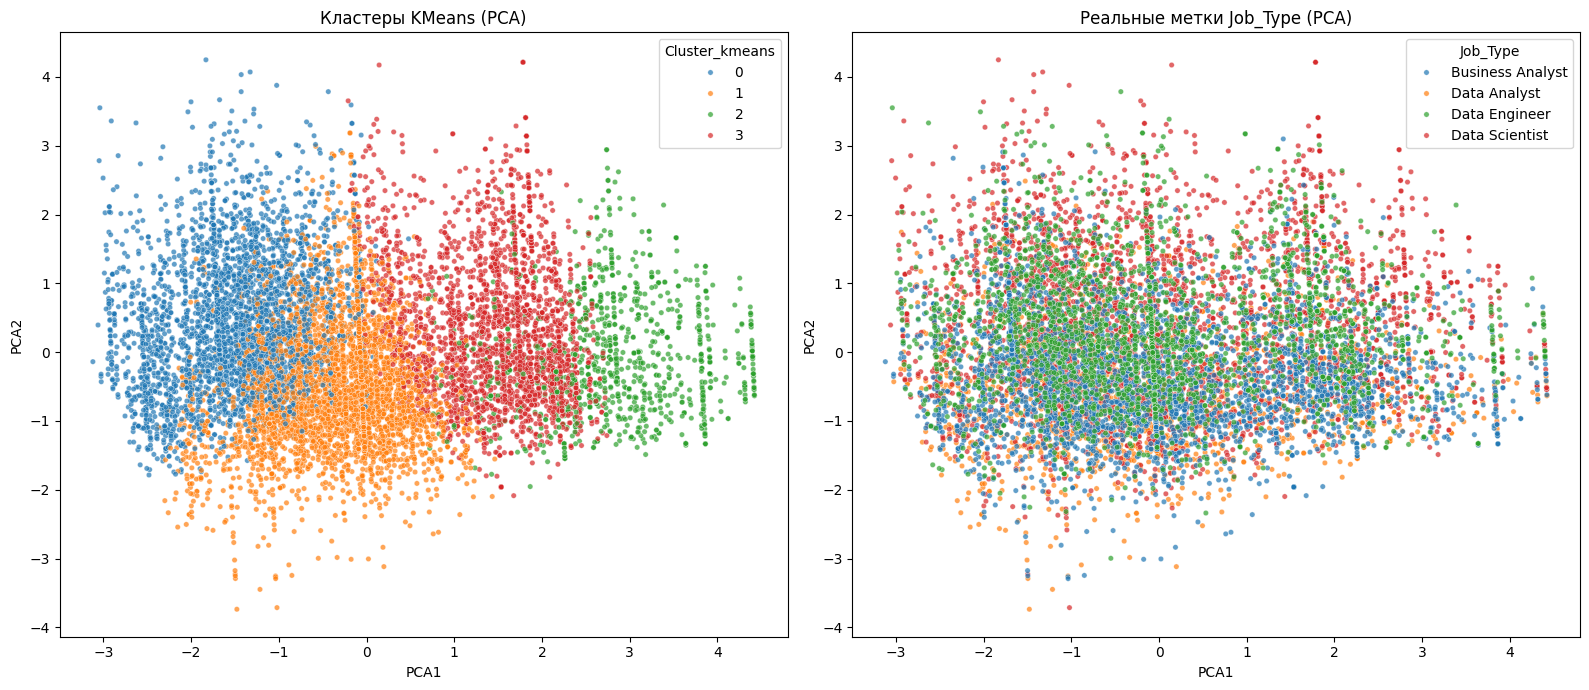

In [117]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_for_clustering)

df_plot = df.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_plot["PCA1"],
    y=df_plot["PCA2"],
    hue=df_plot["Cluster_kmeans"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Кластеры KMeans (PCA)")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=df_plot["PCA1"],
    y=df_plot["PCA2"],
    hue=df_plot["Job_Type"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Реальные метки Job_Type (PCA)")

plt.tight_layout()
plt.show()


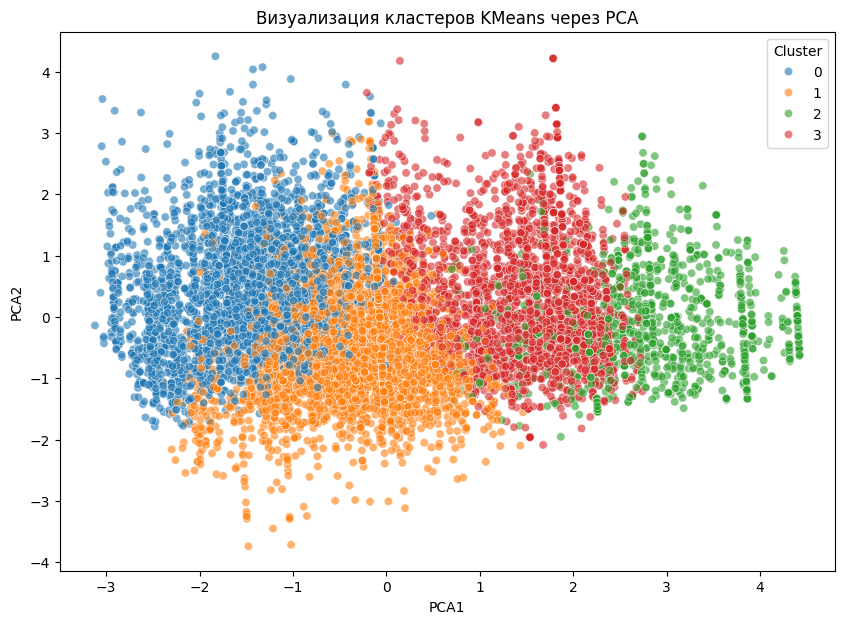

In [118]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_for_clustering)

df_plot = df.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Cluster_kmeans",  # указываем конкретный метод
    palette="tab10",
    alpha=0.6
)
plt.title("Визуализация кластеров KMeans через PCA")
plt.legend(title="Cluster")
plt.show()

#### Agglomerative Clustering

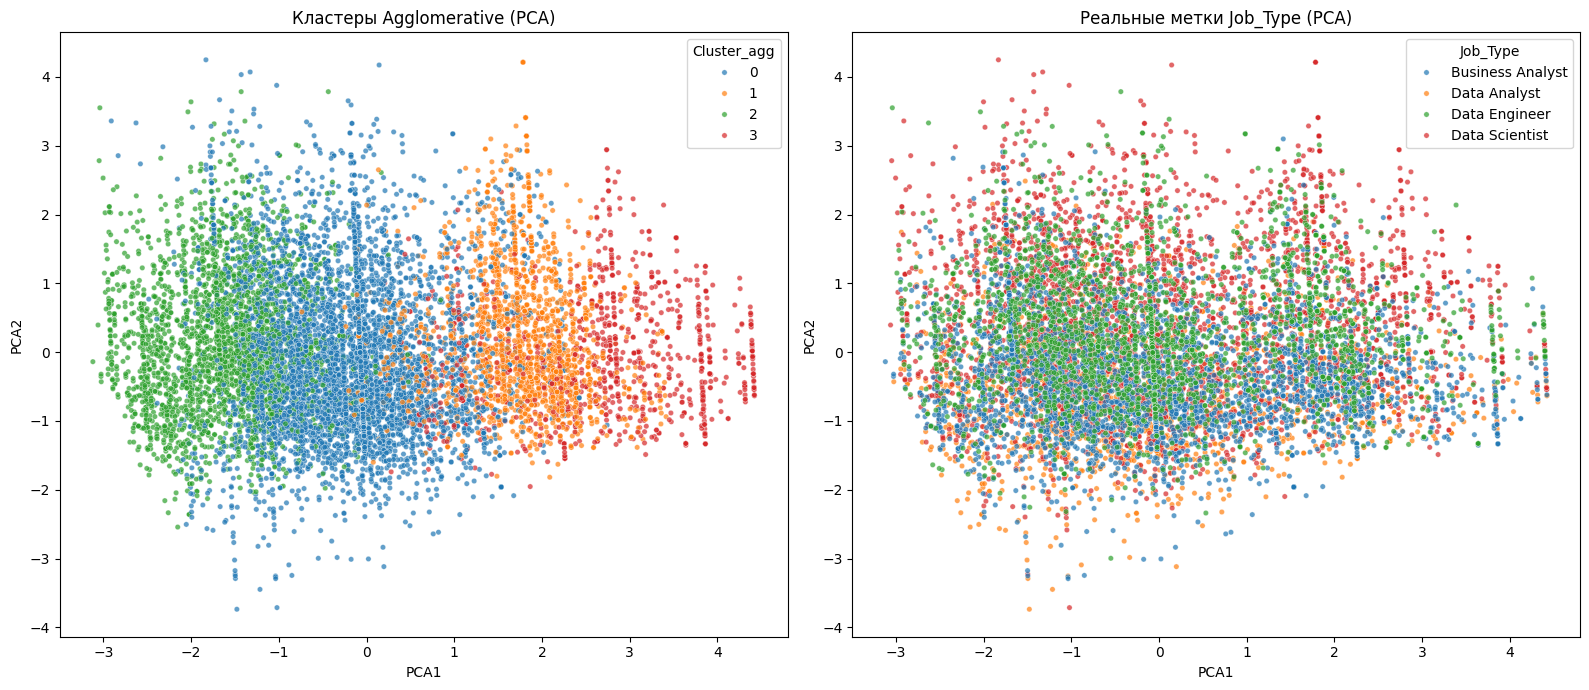

In [119]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_for_clustering)

df_plot = df.copy()
df_plot["PCA1"] = X_pca[:, 0]
df_plot["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_plot["PCA1"],
    y=df_plot["PCA2"],
    hue=df_plot["Cluster_agg"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Кластеры Agglomerative (PCA)")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=df_plot["PCA1"],
    y=df_plot["PCA2"],
    hue=df_plot["Job_Type"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Реальные метки Job_Type (PCA)")

plt.tight_layout()
plt.show()

### TSNE

#### Kmeans

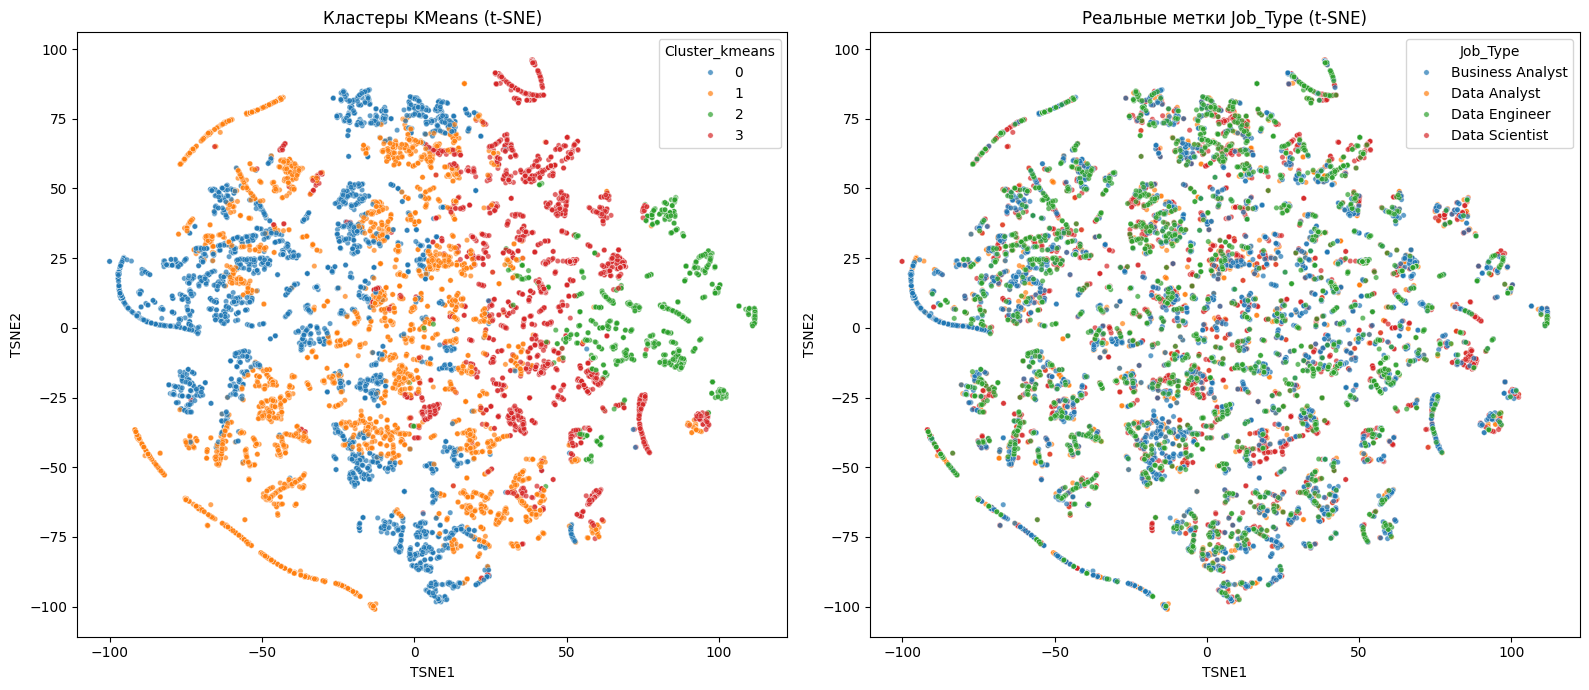

In [121]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_for_clustering)

df_plot = df.copy()
df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_plot["TSNE1"],
    y=df_plot["TSNE2"],
    hue=df_plot["Cluster_kmeans"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Кластеры KMeans (t-SNE)")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=df_plot["TSNE1"],
    y=df_plot["TSNE2"],
    hue=df_plot["Job_Type"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Реальные метки Job_Type (t-SNE)")

plt.tight_layout()
plt.show()

#### Agglomerative Clustering

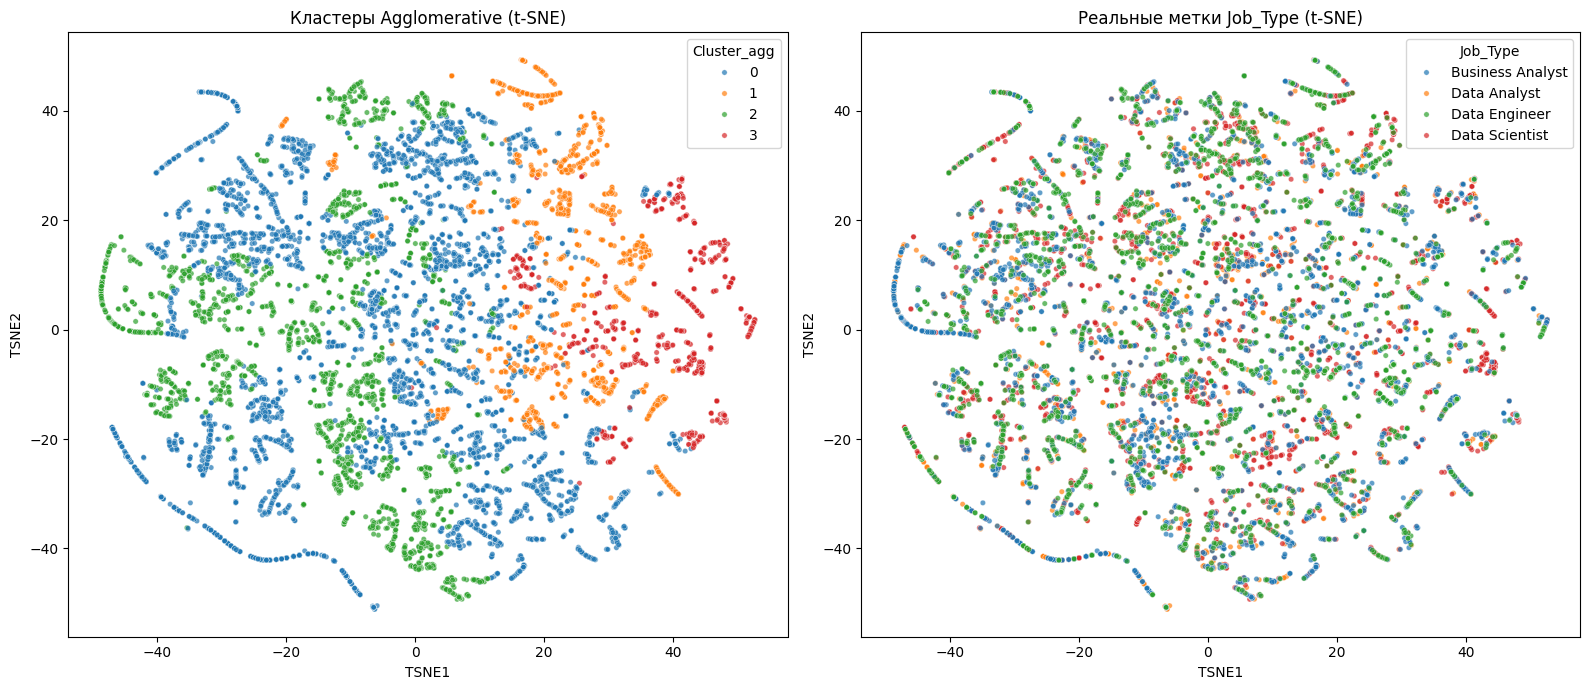

In [122]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_tsne = tsne.fit_transform(X_for_clustering)

df_plot = df.copy()
df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_plot["TSNE1"],
    y=df_plot["TSNE2"],
    hue=df_plot["Cluster_agg"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Кластеры Agglomerative (t-SNE)")

plt.subplot(1, 2, 2)
sns.scatterplot(
    x=df_plot["TSNE1"],
    y=df_plot["TSNE2"],
    hue=df_plot["Job_Type"],
    palette="tab10",
    legend="full",
    s=15,
    alpha=0.7
)
plt.title("Реальные метки Job_Type (t-SNE)")

plt.tight_layout()
plt.show()